In [12]:
import os
from dotenv import load_dotenv
load_dotenv() ## aloading all the environment variable

True

In [13]:
### Build Index

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_ollama import OllamaEmbeddings

### from langchain_cohere import CohereEmbeddings

# Set embeddings
# embd = OpenAIEmbeddings()
embd = OllamaEmbeddings(
    model="nomic-embed-text"
)

# Docs to index
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

# Load
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorstore
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings()
)


retriever=vectorstore.as_retriever()

In [14]:
### Retrieval Grader

from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field


# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

# LLM with function call
# llm = ChatOpenAI(model="gpt-3.5-turbo-0125", temperature=0)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
# llm = ChatOllama(model="granite4", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)
##chain the prompt with the LLM
retrieval_grader = grade_prompt | structured_llm_grader
question = "agent memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='yes'


In [15]:
from langchain_core.output_parsers import StrOutputParser

# llm = ChatOllama(model="granite4", temperature=0)
# llm = ChatOpenAI(model="gpt-4.1-nano", temperature=0)
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
prompt = ChatPromptTemplate.from_messages([
    ("human",
        "You are an assistant for question-answering tasks. Use the following pieces "
        "of retrieved context to answer the question. If you don't know the answer, "
        "just say that you don't know. Use three sentences maximum and keep the "
        "answer concise.\n"
        "Question: {question}\nContext: {context}\nAnswer:")
])

# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

An LLM-powered agent has two types of memory: short-term memory, which is akin to in-context learning, and long-term memory. Long-term memory allows the agent to store and retrieve information over extended periods, often utilizing an external vector store and fast retrieval mechanisms. This capability is crucial for agents to learn from past experiences and inform future behavior.


In [16]:
### Question Re-writer

# LLM
# llm = ChatOpenAI(model="gpt-3.5-turbo-0125", temperature=0)
# llm = ChatOllama(model="granite4", temperature=0)
# llm = ChatOpenAI(model="gpt-4.1-nano", temperature=0)
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'Here are a few options for an improved question, depending on the most likely underlying intent:\n\n**Option 1 (Most common interpretation: AI/Intelligent Agents):**\n\n"What are the different types of memory in AI agents and how do they function?"\n\n**Reasoning for improvement:**\n\n*   **Clarifies "agent":** Specifies "AI agents" or "intelligent agents," which is the most common and relevant context for "agent memory" in modern search.\n*   **Adds specificity to "memory":** Asks about "types" and "function," moving beyond a simple term to inquire about the mechanisms and categories of memory.\n*   **Optimized for web search:** Uses clear, descriptive keywords that search engines can easily match to relevant articles, research papers, and tutorials on AI agent architectures, cognitive models, and memory systems (e.g., short-term, long-term, episodic, semantic memory for AI).\n\n**Other good options depending on specific nuance:**\n\n*   **If looking for implementation details:** "Ho

In [17]:
from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(max_results=3)

In [18]:
from typing import List

from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

In [19]:
from langchain_core.documents import Document


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def web_search(state):
    print("---WEB SEARCH---")
    question = state["question"]

    docs = web_search_tool.invoke({"query": question})

    # TavilySearch mới trả về string, cũ trả về list of dicts
    if isinstance(docs, str):
        web_results = docs
    elif isinstance(docs, list):
        if docs and isinstance(docs[0], dict):
            web_results = "\n".join([d["content"] for d in docs])
        else:
            web_results = "\n".join(docs)
    else:
        web_results = str(docs)

    web_results = Document(page_content=web_results)
    return {"documents": web_results, "question": question}



### Edges
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [20]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()

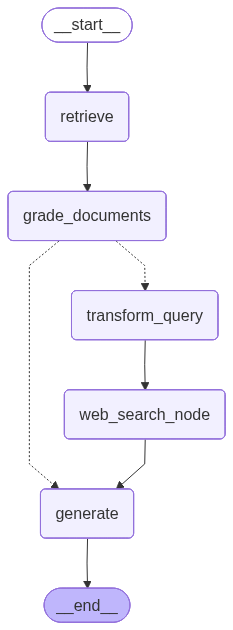

In [21]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [22]:
app.invoke({"question":"What are the types of agent memory?"})

---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
---GENERATE---


{'question': 'What are the types of memory in artificial intelligence agents?',
 'generation': 'AI agents utilize four primary types of memory: in-context (working memory) for active context, episodic memory for past interactions, semantic memory for factual knowledge, and procedural memory for rules and skills. Some frameworks also include organizational context memory for enterprise data agents.',
 'web_search': 'Yes',
 'documents': Document(metadata={}, page_content="{'query': 'What are the types of memory in artificial intelligence agents?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://atlan.com/know/types-of-ai-agent-memory', 'title': 'Types of AI Agent Memory: Episodic, Semantic, Procedural and More', 'content': '# Types of AI Agent Memory: Semantic, Episodic, Procedural, In-Context. AI agents use four memory types formalised in the CoALA framework (Princeton, 2023): in-context (working memory), episodic (past interactions), semantic (fa